# Applied Math 10: Computing for Science and Engineering


## Section 10 : Second-order Ordinary Differential Equations (ODEs)

**Fall 2020**<br/>
<br>


### Learning Goals
The objectives of this Section include:
- the application of python functions for the Euler and Runge-Kutta 2nd order (RK) methods in solving second order ODEs
- solving interesting second order ODEs.

In [1]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt

### Review: for Euler's method (via three point formula for derivative)

A second-order ODE is then given by:

$$ \frac{d^2 u}{dx^2} = g(x,u,u') $$

where $g(u,u',x)$ is a given function of the function $u$, its first derivative $$u'=\frac{du}{dx}, $$ and the variable $x$.  We also need to know the value of the function $u(x)$ and its derivative $u'(x)$ for some specific value of $x$ (the "initial" or "boundary" conditions), so that we can try to solve for the function $u(x)$ that satisfies this equation. 

$$u'(x_{n+1})=u'(x_{n-1}) + 2 \; \Delta x \; g(x_n, u(x_n), u'(x_n)) ~~~~ (1)$$

$$u(x_{n+1})=u(x_{n-1}) + 2 \; \Delta x \; u'(x_n) ~~~~~~~~~~~~~~~~~~~~~~~~~~~ (2) $$


We will code these formulas with the replacements $\bf{u'}$ by $\bf{ud}$, $\bf{u}$ by $\bf{uf}$, and $\bf{g(x,u,u')}$ by $\bf{gf}$.

### Functions developed in the Lab:

#### Function for the Euler's method

In [2]:
#Function to integrate a second-order ODE 
#Euler's method with three point formula for derivative
#-------------------------------------------------------------------------
#Note: We are using the following replacements in the formulae:
#    ud for u', uf for u, gf for g
#---------------------------------------------------------------------------

def ode2_euler(Nx,xmin,xmax,uf0,ud0):
    #Nx: Number of points to be used for integration.
    #xmin, xmax: Integration limits
    #uf0: Intial condition on uf at xmin
    #ud0: Initial condition on ud at xmin

    x = np.linspace(xmin, xmax, Nx)
    dx = x[1] - x[0]
    dx2=2.0*dx

    uf=np.zeros(Nx)
    ud=np.zeros(Nx)
    
    #Initial (boundary) conditions
    uf[0]=uf0
    ud[0]=ud0
    #We will write a separate python function for 
    # gf(x[n],uf[n],ud[n]) later. The initial value will be:

    gf0=gf(x[0],uf[0],ud[0])
    
    #Also:
    ud[1]=ud[0]+dx*gf0
    uf[1]=uf[0]+dx*ud[0]

    for n in range(1,Nx-1):
        '''Fill in the code for ud[n+1] and uf[n+1]'''
        '''Refer to Equations (1) and (2)'''
      #---------------------------------------------
        ud[n+1]=ud[n-1]+dx2*gf(x[n],uf[n],ud[n])
        uf[n+1]=uf[n-1]+dx2*ud[n]
      #----------------------------------------------
    return uf   

#### Function for the Runge-Kutta 2nd order method

Starting with second-order equation, 
we can break it up to a couple of first-order equations:

$$\frac{d^2 u}{d x^2} = g(x,u,u')$$

$$\frac{d u}{d x} = v 
\Rightarrow 
\frac{d v}{dx} = \frac{d^2 u}{d x^2} = g(u,v,x) $$

Now we deal with the two coupled first-order equations, and use the second-order RK method:

$$\frac{d u}{dx} = v, \; \; \; \frac{d v}{dx} = g(x,u,v)$$

$$k^{(1)}_n =v_n, \; \; \; l^{(1)}_n =g(x_n,u_n,v_n)$$

$$k^{(2)}_n=v_n+\frac{h l^{(1)}_n}{2},\; \; \; 
l^{(2)}_n=g(x_n+\frac{h}{2},u_n+\frac{h k^{(1)}_n}{2}, v_n+\frac{h l^{(1)}_n}{2} )$$ 

$$k^{(3)}_n = v_n+h l^{(2)}_n, \; \; \; 
l^{(3)}_n = g(x_n+h,u_n+h k^{(2)}_n, v_n+h l^{(2)}_n)
$$ 

$$u_{n+1} = u_n + \frac{h}{4} \left [ k^{(1)}_n + 2 \; k^{(2)}_n + k^{(3)}_n \right ], \; \; \; 
v_{n+1} = v_n + \frac{h}{4} \left [ l^{(1)}_n + 2 \; l^{(2)}_n + l^{(3)}_n 
\right ]
$$

The code follows the following substitutions: $\bf{h}$ by $\bf{dx}$, $\bf{u}$ by $\bf{uf}$, $\bf{v}$ by $\bf{vf}$, $\bf{g(x,u,u')}$ by $\bf{gf}$, $\bf{f(x,u,u')}$ by $\bf{ff}$, $\bf{k_n^{(p)}}$ by $\bf{knp}$, $\bf{l_n^{(p)}}$ by $\bf{lnp}$ where $\bf{p}$ takes the values 1, 2, and 3.

In [3]:
def ode2_rk2(Nx, xmin, xmax, uf0, vf0):
    #Diff eqns of form: 
    #                 d(uf)/dx=ff(x,uf,vf)
    #                 d(vf)/dx=gf(x,uf,vf)
    #Nx: Number of points to be used for integration
    #xmin, xmax: Initial and final values of the independent variable (x)
    #uf0, vf0: Initial (boundary) values of the dependent variables at x=xmin
     
    x = np.linspace(xmin, xmax, Nx)
    dx = x[1] - x[0] # dx = h 
    
    uf = np.zeros(Nx) # uf = u 
    vf = np.zeros(Nx) # vf = v 
    
    #Initial conditions on u and v
    uf[0] = uf0
    vf[0] = vf0
    
    #We define two variables that minimize repetitive computations (such as multiplying or dividing dx by 2)
    #You can use these below while coding
    
    dxovr4 = dx / 4.0
    dxovr2 = dx / 2.0

    for n in range(Nx - 1):
        #We need to suppy the functions ff(x,uf,vf) and gf(x,uf,vf)
        
        #Formulae can be coded as:
        kn1 = ff(x[n], uf[n], vf[n]) 
        ln1 = gf(x[n], uf[n], vf[n])

        kn2 = ff(x[n] + dxovr2, uf[n] + dxovr2 * kn1, vf[n]+dxovr2 * ln1)
        ln2 = gf(x[n] + dxovr2, uf[n] + dxovr2 * kn1, vf[n]+dxovr2 * ln1)

        ''' Code remaining formulae'''
        #--------------------------------------------------------------------
        kn3 = ff(x[n] + dx, uf[n] + dx * kn2, vf[n]+dx * ln2)
        ln3 = gf(x[n] + dx, uf[n] + dx * kn2, vf[n]+dx * ln2)

             
        uf[n+1] = uf[n] + dxovr4 * (kn1 + 2.0 * kn2 + kn3)
        vf[n+1] = vf[n] + dxovr4 * (ln1 + 2.0 * ln2 + ln3)
        #-------------------------------------------------------------------
    return uf

## Problem 1
The following equation arises while describing steady-state heat conduction across a cylindrical pipe wall. The inside of the pipe ($x_0=0.1$) is held at 373 K and the outside at 300 K. Solve the equation using Runge-Kutta method:

$$\frac{d^2 u}{dx^2}=-\frac{1}{x}\frac{du}{dx}$$

over the domain $0.1\le x\le 0.5$. With $x_0=0.1$, also given are:

$$u(x_0)=373.0$$ and $$\frac{du}{dx}(x_0)=-453.6$$ Compare it with the 
exact solution:

$$utrue=373.0-45.36*\ln\left (\frac{x}{x_{0}}\right ) $$

where $\ln$ is the natural logarithm.

Note: In this problem (steady-state heat conduction across a cylindrical pipe wall) $u(t)$ represents the temperature ($T$), and $x$ represents the radial position (from the cylinder's central axis).

In [45]:
# your code here


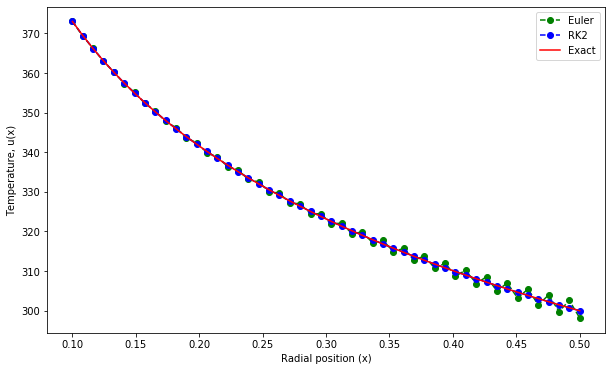

In [4]:
# Solution

# Heat conduction problem

Nx=50
xmin=0.1
xmax=0.50
x=np.linspace(xmin,xmax,Nx)

uf0=373.0
ud0=-453.6


#Define the functions gf and ff
def gf(x,uf,ud):
    return -1.0*ud/x

def ff(x,uf,ud):
    return ud

# True solution

utrue=373.0-45.36*np.log(x/xmin)


# Find the solution using Euler method

ufn=ode2_euler(Nx,xmin,xmax,uf0,ud0)

# Find the solution using the Runge-Kutta (2nd order) method

uf2=ode2_rk2(Nx, xmin, xmax, uf0, ud0)

#Compare the solutions
fig = plt.figure(figsize=(10,6))
plt.plot(x,ufn,'go--', label="Euler")               
plt.plot(x,uf2,'bo--', label="RK2")
plt.plot(x,utrue,'r-', label="Exact")
plt.xlabel('Radial position (x)')
plt.ylabel('Temperature, u(x)')
plt.legend()
plt.show()


__________________________________________________________________________________________________________________________

## Problem 2
 
Consider the simplified motion of an object of mass  𝑚  as it travels toward Earth under the attraction of the gravitational force, described by the differential equation

$$\frac {d^2 \bf{r}}{dt^2} = - \frac{G \ M_E \ \bf{r}}{r^3}$$

which can be recast as

$$\frac {d^2 r}{dt^2} = - \frac{G \ M_E}{r^2}$$

where $\bf{𝐫}$ is the object's radial distance vector from the center of the Earth ($r$ is its magnitude), $M_E$ is the mass of the Earth, and $G$ is the universal gravitational constant.

In this problem, you have to determine the speed with which the object will reach the surface of the Earth (assume that the object starts from rest (initial speed is 0) and the radius of Earth is $R_E \approx 6400 \ km$) considering that the overall travel time is 55250 s, and that  the object's initial distance to the center of the Earth is $r_{init} = r(0) = 100,000,000 \ m$.

Solve the differential equation (by using the methods and functions developed in Lecture and Lab) to find the approximate solution $r(t)$, plot $r(t)$ a function of time $t$, and determine the speed of impact. 

In [47]:
# your code here


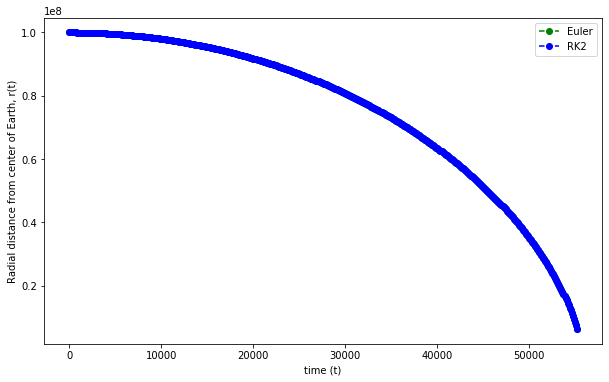

Speed of impact: -10344.58 m/s, Distance from center of Earth: 6353 km


In [48]:
# Solution

Nx=500
xmin=0
xmax=55250
x=np.linspace(xmin,xmax,Nx)
dx = x[1] - x[0]

G_const = 6.67408 * 10**(-11)       # Gravitational constant

M = 5.972 * 1e24                 # Mass of Earth

uf0 = 100000000
ud0 = 0

#Define the functions gf and ff. 
#These are called from within the Euler and RK functions. They need to have the
#same names as used in those functions.They need to have the same number of arguments.
#The variable names can be different.

def gf(x,uf,ud):
    return - G_const * M / (uf**2)

def ff(x,uf,ud):
    return ud

# Find the solution using Euler method

ufn=ode2_euler(Nx,xmin,xmax,uf0,ud0)

# Find the solution using the Runge-Kutta (RK2) method

uf2f=ode2_rk2(Nx, xmin, xmax, uf0, ud0)

#Compare the solutions
fig = plt.figure(figsize=(10,6))
plt.plot(x,ufn,'go--', label="Euler")               
plt.plot(x,uf2f,'bo--', label="RK2")
plt.xlabel('time (t)')
plt.ylabel('Radial distance from center of Earth, r(t)')
plt.legend()
plt.show()

speed = (uf2f[-1]-uf2f[-2])/dx

print(f'Speed of impact: {speed:.2f} m/s, Distance from center of Earth: {uf2f[-1]/1000:.0f} km')

## Problem 3

As they have been written, functions `ode2_euler` and `ode2_rk2` functions return only `uf`. However the functions calculate `vf` (which is the first derivative of uf) at the same time.

Solve the previous Problem, but modify (slightly) the `ode2_rk2` function in order to return both `uf` and `vf`. Apply the modified function to Problem 2 in order to plot both $r(t)$ and $\frac {dr}{dt} (t)$.

In [49]:
# your code here


In [7]:
# Solution
# Modify the RK2 function

def ode2_rk2_mod(Nx, xmin, xmax, uf0, vf0):
    #Diff eqns of form: 
    #                 d(uf)/dx=ff(x,uf,vf)
    #                 d(vf)/dx=gf(x,uf,vf)
    #Nx: Number of points to be used for integration
    #xmin, xmax: Initial and final values of the independent variable (x)
    #uf0, vf0: Initial (boundary) values of the dependent variables at x=xmin
     
    x = np.linspace(xmin, xmax, Nx)
    dx = x[1] - x[0] # dx = h 
    
    uf = np.zeros(Nx) # uf = u 
    vf = np.zeros(Nx) # vf = v 
    
    #Initial conditions on u and v
    uf[0] = uf0
    vf[0] = vf0
    
    #We define two variables that minimize repetitive computations (such as multiplying or dividing dx by 2)
    #You can use these below while coding
    
    dxovr4 = dx / 4.0
    dxovr2 = dx / 2.0

    for n in range(Nx - 1):
        #We need to suppy the functions ff(x,uf,vf) and gf(x,uf,vf)
        
        #Formulae can be coded as:
        kn1 = ff(x[n], uf[n], vf[n]) 
        ln1 = gf(x[n], uf[n], vf[n])

        kn2 = ff(x[n] + dxovr2, uf[n] + dxovr2 * kn1, vf[n]+dxovr2 * ln1)
        ln2 = gf(x[n] + dxovr2, uf[n] + dxovr2 * kn1, vf[n]+dxovr2 * ln1)

        ''' Code remaining formulae'''
        #--------------------------------------------------------------------
        kn3 = ff(x[n] + dx, uf[n] + dx * kn2, vf[n]+dx * ln2)
        ln3 = gf(x[n] + dx, uf[n] + dx * kn2, vf[n]+dx * ln2)

             
        uf[n+1] = uf[n] + dxovr4 * (kn1 + 2.0 * kn2 + kn3)
        vf[n+1] = vf[n] + dxovr4 * (ln1 + 2.0 * ln2 + ln3)
        #-------------------------------------------------------------------
    return uf, vf

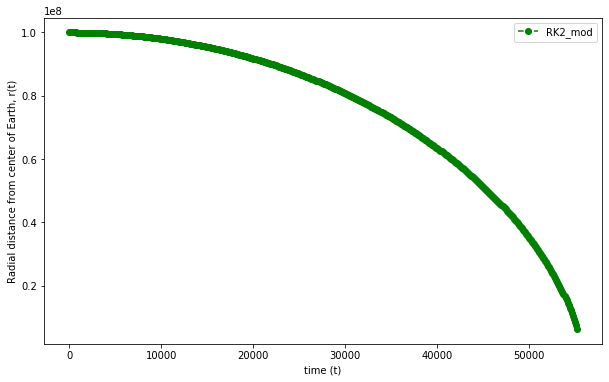

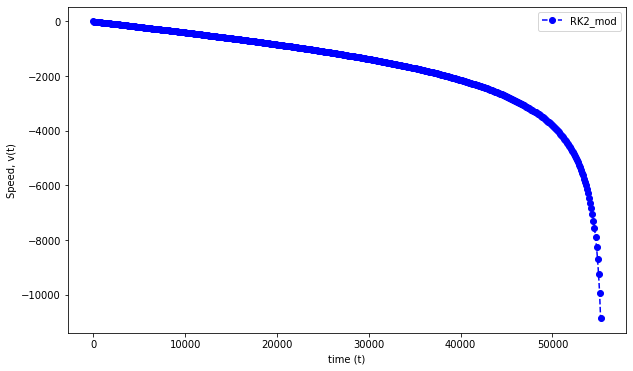

Speed of impact: -10846.05 m/s, Distance from center of Earth: 6353 km


In [51]:

# Find the solution using the modified Runge-Kutta (RK2) method

Nx=500
xmin=0
xmax=55250
x=np.linspace(xmin,xmax,Nx)
dx = x[1] - x[0]

G_const = 6.67408 * 10**(-11)       # Gravitational constant

M = 5.972 * 1e24                 # Mass of Earth

uf0 = 100000000
ud0 = 0

#Define the functions gf and ff. 
#These are called from within the Euler and RK functions. They need to have the
#same names as used in those functions.They need to have the same number of arguments.
#The variable names can be different.

def gf(x,uf,ud):
    return - G_const * M / (uf**2)

def ff(x,uf,ud):
    return ud


uf_mod, vf_mod =ode2_rk2_mod(Nx, xmin, xmax, uf0, ud0)

#Compare the solutions
fig = plt.figure(figsize=(10,6))
plt.plot(x,uf_mod,'go--', label="RK2_mod")   
plt.xlabel('time (t)')
plt.ylabel('Radial distance from center of Earth, r(t)')
plt.legend()
plt.show()

fig = plt.figure(figsize=(10,6))
plt.plot(x,vf_mod,'bo--', label="RK2_mod")
plt.xlabel('time (t)')
plt.ylabel('Speed, v(t)')
plt.legend()
plt.show()

print(f'Speed of impact: {vf_mod[-1]:.2f} m/s, Distance from center of Earth: {uf_mod[-1]/1000:.0f} km')

___________________________________________________________________________________________________________________________

### Hint for HW10 problem:

The equation of motion can also be recast as a system of two coupled equations

$$\frac {d^2 x}{dt^2} = - \frac{G \ M_E \ x}{(x^2 + y^2)^{3/2}}$$

and

$$\frac {d^2 y}{dt^2} = - \frac{G \ M_E \ y}{(x^2 + y^2)^{3/2}}$$

where $x(t)$ and $y(t)$ are the object's positions in the cartesian $x-$ and $y-$ axes.

As both $x(t)$ and $y(t)$ are changing at each time step, you can implement the approximate methods (e.g. Euler) as described in Lecture, or use the functions develop in Lab but call them for each time step. You can also write your own code to solve this problem (using Euler and/or RK methods).

__________________________________________________________________________________________________________________________

___________________________________________________________________________________________________________________________